In [3]:
# imports
import matplotlib.pyplot as plt
import numpy as np
import os
from autoemulate import AutoEmulate
from autoemulate.core.plotting import create_and_plot_slice
from lipb_surrogate import FestimProblem
import sys

/home/kaelyn/anaconda3/envs/tes-pav-env/lib/python3.12/site-packages/pybtex/plugin/__init__.py:26: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Reynolds number for LiPb at 0.5m/s is 543615.9929158624.
Schmidt number for LiPb is 144.8770408864817.
Density of LiPb at 603.15K is 9802.2938935kg/m3.
Initial turbulence kinetic energy for LiPb: 0.0009375000000000002 m2/s2
Initial turbulence dissipation rate for LiPb: 3.628235300029708e-05 m2/s3
Initial specific dissipation rate for LiPb: 0.43001307259611343 1/s


In [4]:
simulator = FestimProblem(
    parameters_range={
        "v_in": (0.01, 2.1),
        "c_in": (np.log10(1e15), np.log10(1e25)),
    },  # ranges for each variable
    output_names=["c_out", "permeation_flux"],
)

In [5]:
# load training data 
# TODO: make paths generic

X = np.loadtxt("/home/kaelyn/Fusion-TES-Modeling/lipb_emulators/emulator_1/inputs_updated.csv", delimiter=",")
Y = np.loadtxt("/home/kaelyn/Fusion-TES-Modeling/lipb_emulators/emulator_1/outputs.csv", delimiter=",")

In [6]:
# train model 

ae = AutoEmulate(X, Y, log_level="info", models=["GaussianProcessRBF"])
emulator = [r for r in ae.results if r.model_name == "GaussianProcessRBF"][0]

print(f"Selected model: {emulator.model_name} with id: {emulator.id}")

ae.summarize()

INFO    2026-05-06 11:55:44,698 - autoemulate - Comparing ['GaussianProcessRBF']
INFO    2026-05-06 11:55:44,700 - autoemulate - Running Model: GaussianProcessRBF: 1/1 (attempt 1/3)
INFO    2026-05-06 11:56:16,862 - autoemulate - Finished running Model: GaussianProcessRBF

INFO    2026-05-06 11:56:16,863 - autoemulate - Using metric 'r2' to determine best result.
Selected model: GaussianProcessRBF with id: 0


,model_name,x_transforms,y_transforms,params,r2_test,r2_test_std,rmse_test,rmse_test_std,r2_train,r2_train_std,rmse_train,rmse_train_std
0,GaussianProcessRBF,[StandardizeTransform()],[StandardizeTransform()],"{'epochs': 100, 'lr': 0.05, 'likelihood_cls': ...",0.73105,0.354922,0.115755,0.03239,0.996123,0.00174,0.076761,0.011467


In [7]:
# save the model
path = "lipb_emulators/emulator_1"
if not os.path.exists(path):
    os.makedirs(path)

emulator_filepath = ae.save(emulator, path, use_timestamp=True)
print("Model and metadata saved to: ", emulator_filepath)

INFO    2026-05-06 11:56:19,767 - autoemulate - GaussianProcessRBF_0_20260506_115619.joblib saved to lipb_emulators/emulator_1/GaussianProcessRBF_0_20260506_115619
INFO    2026-05-06 11:56:19,779 - autoemulate - Metadata saved to lipb_emulators/emulator_1/GaussianProcessRBF_0_20260506_115619_metadata.csv
Model and metadata saved to:  lipb_emulators/emulator_1/GaussianProcessRBF_0_20260506_115619


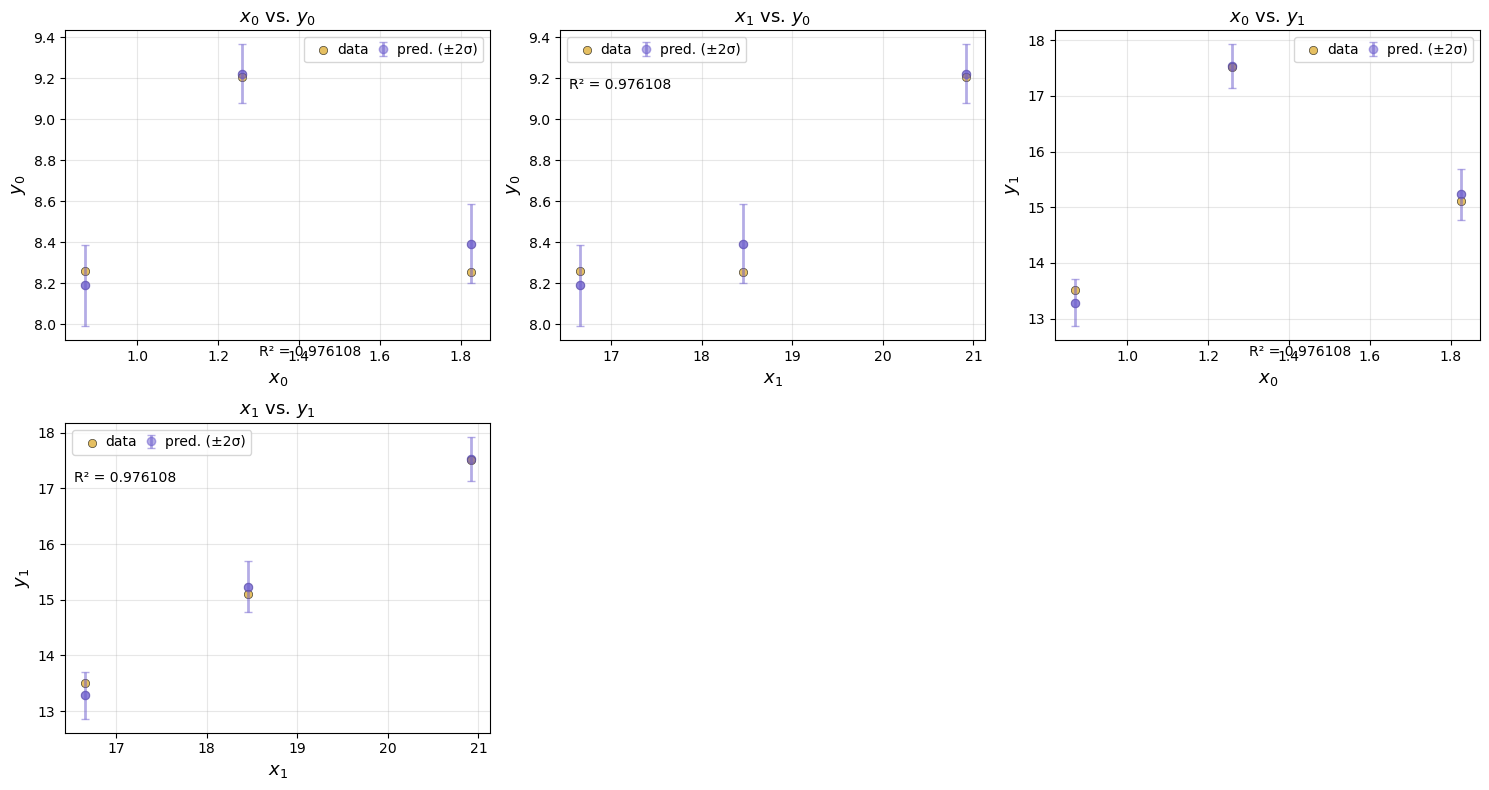

In [8]:
# plotting
ae.plot(emulator)

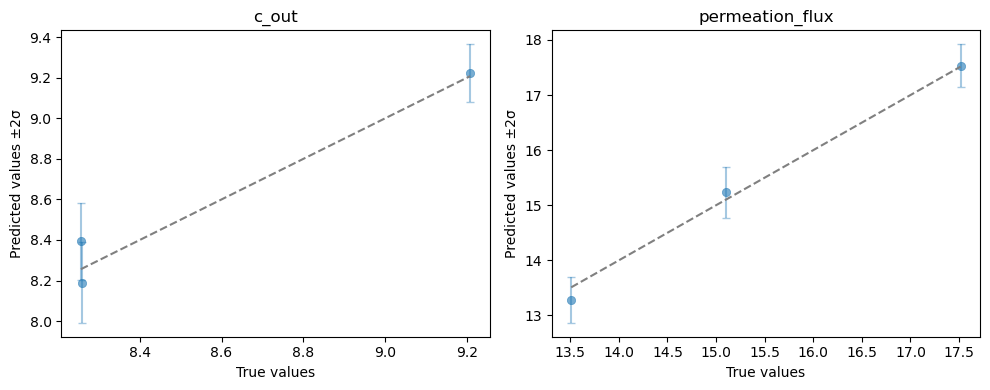

In [9]:
# plot predictions
ae.plot_preds(emulator, output_names=simulator.output_names)

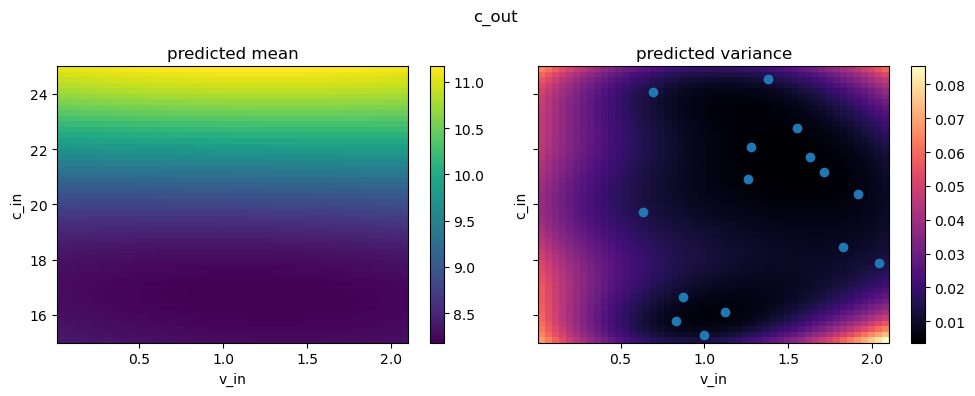

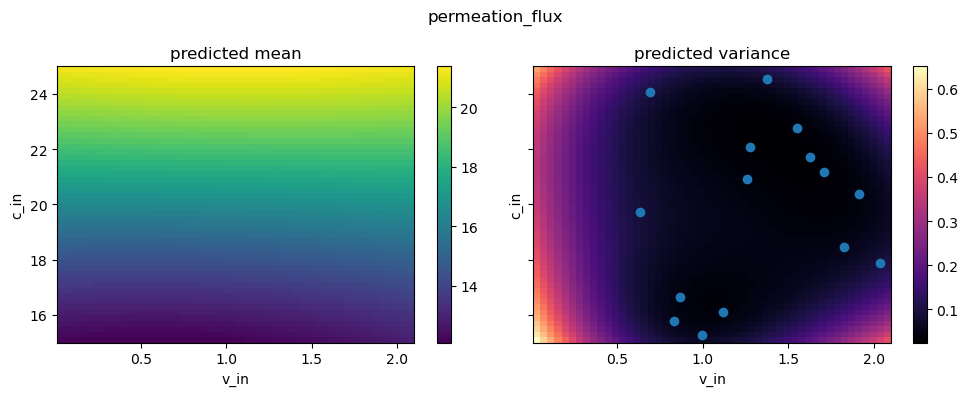

In [ ]:
# plot mean and variance
for i in range(2):
    fig, axs = create_and_plot_slice(
        emulator.model,
        output_idx=i,
        parameters_range=simulator.parameters_range, 
        quantile=0.5,
        param_pair=(0, 1),
    )
    plt.scatter(X[:, 0], X[:, 1])
    plt.suptitle(f"{simulator.output_names[i]}")


In [11]:
# sensitivity analysis 
from autoemulate.core.sensitivity_analysis import SensitivityAnalysis

problem = {
    'num_vars': simulator.in_dim,
    'names': simulator.param_names,
    'bounds': simulator.param_bounds,
    'output_names': simulator.output_names,
}
sa = SensitivityAnalysis(emulator.model, problem=problem)
sobol_df = sa.run("sobol")
sobol_df

,output,parameter,index,value,confidence
0,c_out,v_in,S1,0.000227,0.002392
1,c_out,c_in,S1,0.999379,0.068584
0,c_out,v_in,ST,0.000830,0.000075
1,c_out,c_in,ST,1.000086,0.061339
0,c_out,"[v_in, c_in]",S2,0.000641,0.003944
0,permeation_flux,v_in,S1,0.001344,0.004048
1,permeation_flux,c_in,S1,0.997957,0.069801
0,permeation_flux,v_in,ST,0.002300,0.000323
1,permeation_flux,c_in,ST,0.998805,0.061396
0,permeation_flux,"[v_in, c_in]",S2,0.000997,0.007253


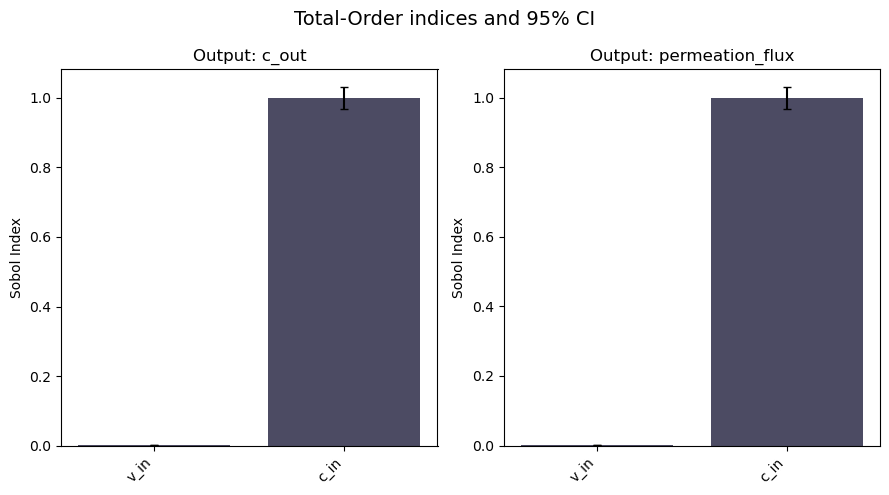

In [12]:
sa.plot_sobol(sobol_df, index="ST", figsize=(9, 5)) 

In [13]:
# morris sensitivity analysis
morris_df = sa.run("morris")
morris_df

,output,parameter,mu,mu_star,sigma,mu_star_conf
0,c_out,v_in,0.027969,0.102481,0.112813,0.003345
1,c_out,c_in,3.051589,3.051589,1.103929,0.070076
2,permeation_flux,v_in,0.351243,0.429336,0.417815,0.022940
3,permeation_flux,c_in,9.165215,9.165215,0.480068,0.029852


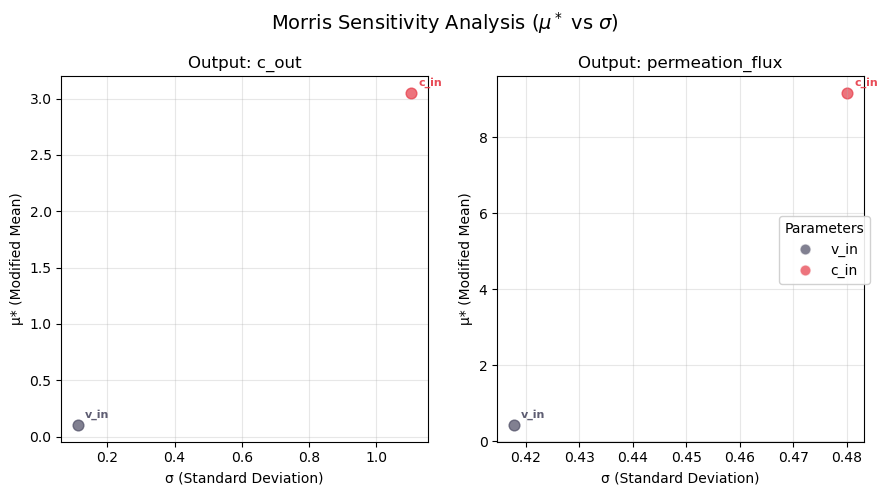

In [14]:
sa.plot_morris(morris_df, figsize=(9, 5))